# Regresión Lineal Múltiple
## Impacto de las Redes Sociales en la Salud Mental de los Adolescentes
**Variable objetivo: `stress_level` (Nivel de estrés 1–10)**

In [3]:
# Tratamiento de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from scipy.stats import pearsonr
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Configuración matplotlib
plt.rcParams['image.cmap'] = "bwr"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Cargando los datos

df = pd.read_excel('datosestresyansiedad.xlsx')
print("-" * 50)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n")
print("-" * 50)
print(df.dtypes)
print("-" * 50)
df.info()
print("-" * 50)
print(df.head())

--------------------------------------------------
Dimensiones: 1200 filas x 13 columnas

--------------------------------------------------
age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
anxiety_level                 int64
addiction_level               int64
depression_label              int64
stress_level                  int64
dtype: object
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 

In [5]:
# Observando valores nulos
df.isna().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
anxiety_level,0


## ANÁLISIS EXPLORATORIO (VISUALIZACIÓN)

In [6]:
# Estadísticas descriptivas
print(df.describe().round(2))

           age  daily_social_media_hours  sleep_hours  \
count  1200.00                   1200.00      1200.00   
mean     15.93                      4.54         6.45   
std       2.02                      2.03         1.44   
min      13.00                      1.00         4.00   
25%      14.00                      2.80         5.20   
50%      16.00                      4.50         6.50   
75%      18.00                      6.30         7.60   
max      19.00                      8.00         9.00   

       screen_time_before_sleep  academic_performance  physical_activity  \
count                   1200.00               1200.00            1200.00   
mean                       1.74                  2.99               1.01   
std                        0.72                  0.58               0.58   
min                        0.50                  2.00               0.00   
25%                        1.10                  2.50               0.50   
50%                        1.8

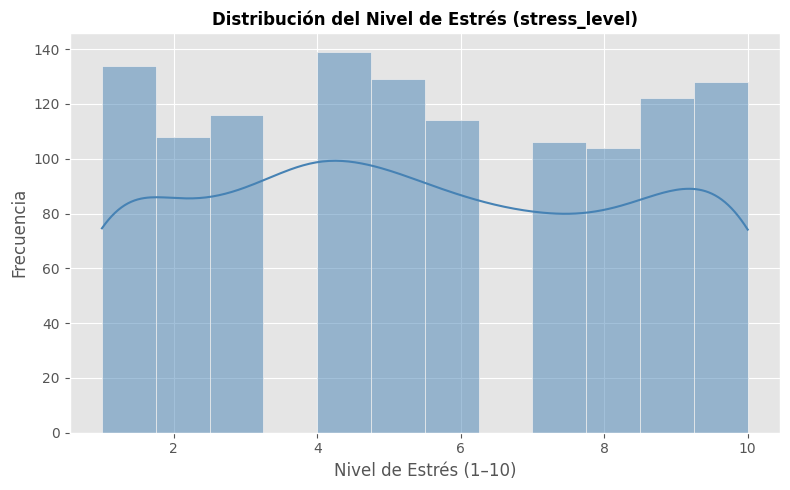

In [7]:
# Distribución de la variable objetivo stress_level
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.histplot(
    data    = df,
    x       = 'stress_level',
    kde     = True,
    color   = 'steelblue',
    ax      = ax
)
ax.set_title('Distribución del Nivel de Estrés (stress_level)', fontsize=12, fontweight='bold')
ax.set_xlabel('Nivel de Estrés (1–10)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

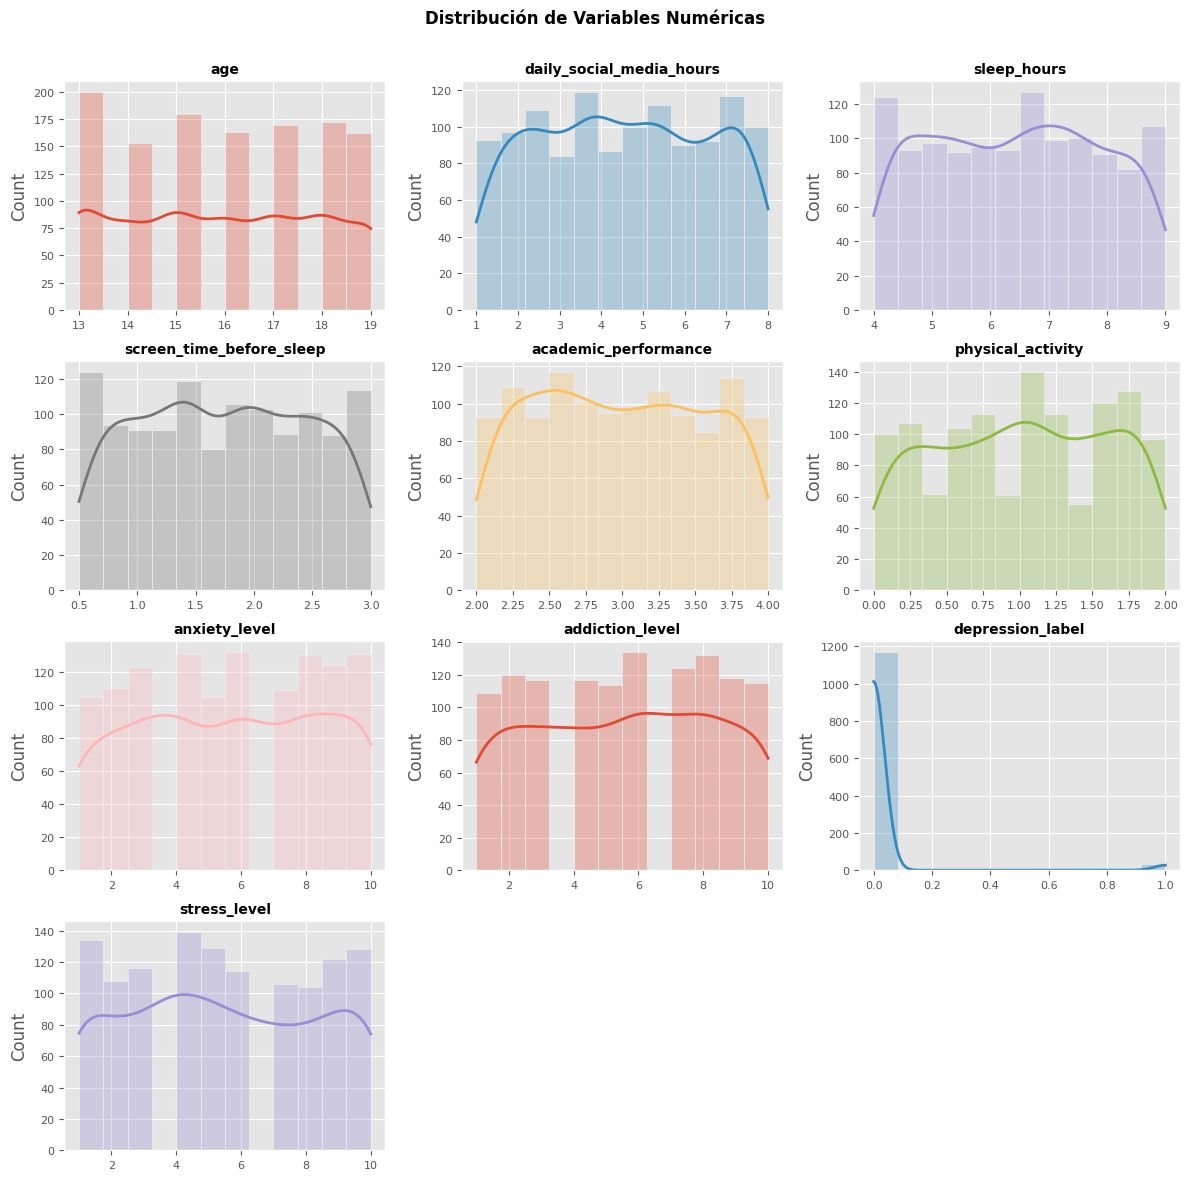

In [8]:
# Distribución de todas las variables numéricas
columnas_numeric = df.select_dtypes(include=['float64', 'int64']).columns
n_cols = 3
n_rows = int(np.ceil(len(columnas_numeric) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 3))
axes = axes.flat

for i, colum in enumerate(columnas_numeric):
    sns.histplot(
        data     = df,
        x        = colum,
        stat     = "count",
        kde      = True,
        color    = (list(plt.rcParams['axes.prop_cycle']) * 3)[i]["color"],
        line_kws = {'linewidth': 2},
        alpha    = 0.3,
        ax       = axes[i]
    )
    axes[i].set_title(colum, fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)
    axes[i].set_xlabel('')

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.subplots_adjust(top=0.92)
fig.suptitle('Distribución de Variables Numéricas', fontsize=12, fontweight='bold')
plt.show()

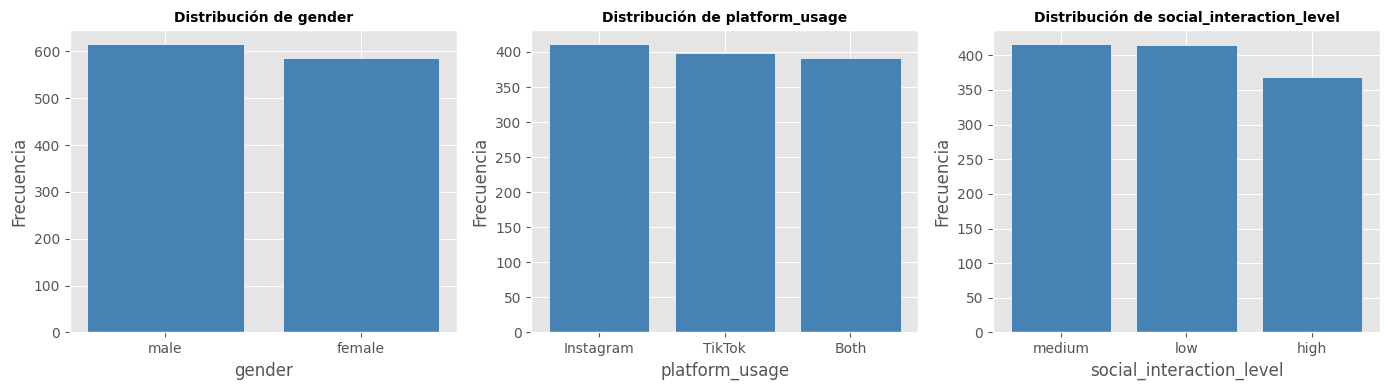

In [9]:
# Distribución de variables categóricas
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(cat_cols):
    conteo = df[col].value_counts()
    axes[i].bar(conteo.index, conteo.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Relación entre variables

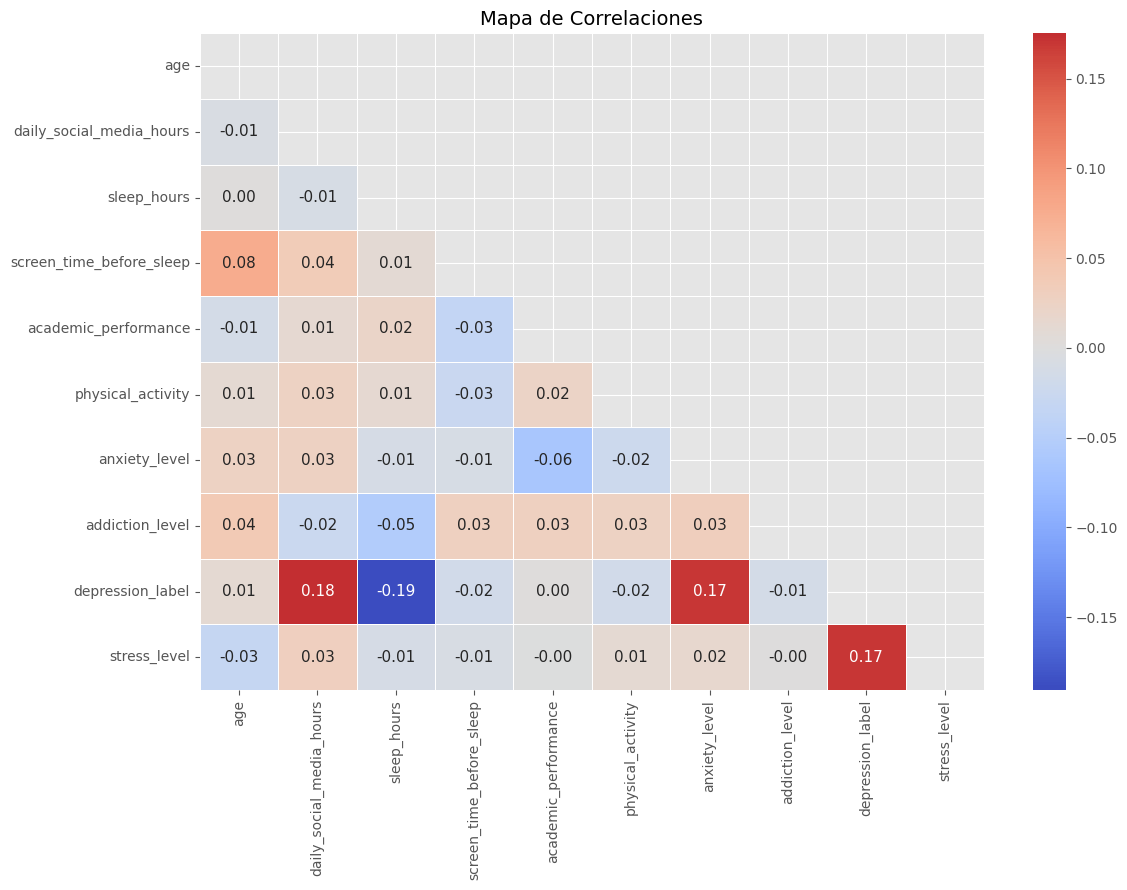

In [10]:
# Mapa de correlaciones (solo variables numéricas)
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 11}, ax=ax
)
ax.set_title('Mapa de Correlaciones', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Correlaciones con stress_level ordenadas
print("\n--- Correlación con stress_level ---")
corr_stress = corr_matrix['stress_level'].drop('stress_level').sort_values()
print(corr_stress.round(3))


--- Correlación con stress_level ---
age                        -0.031
sleep_hours                -0.011
screen_time_before_sleep   -0.009
academic_performance       -0.001
addiction_level            -0.000
physical_activity           0.012
anxiety_level               0.016
daily_social_media_hours    0.031
depression_label            0.170
Name: stress_level, dtype: float64


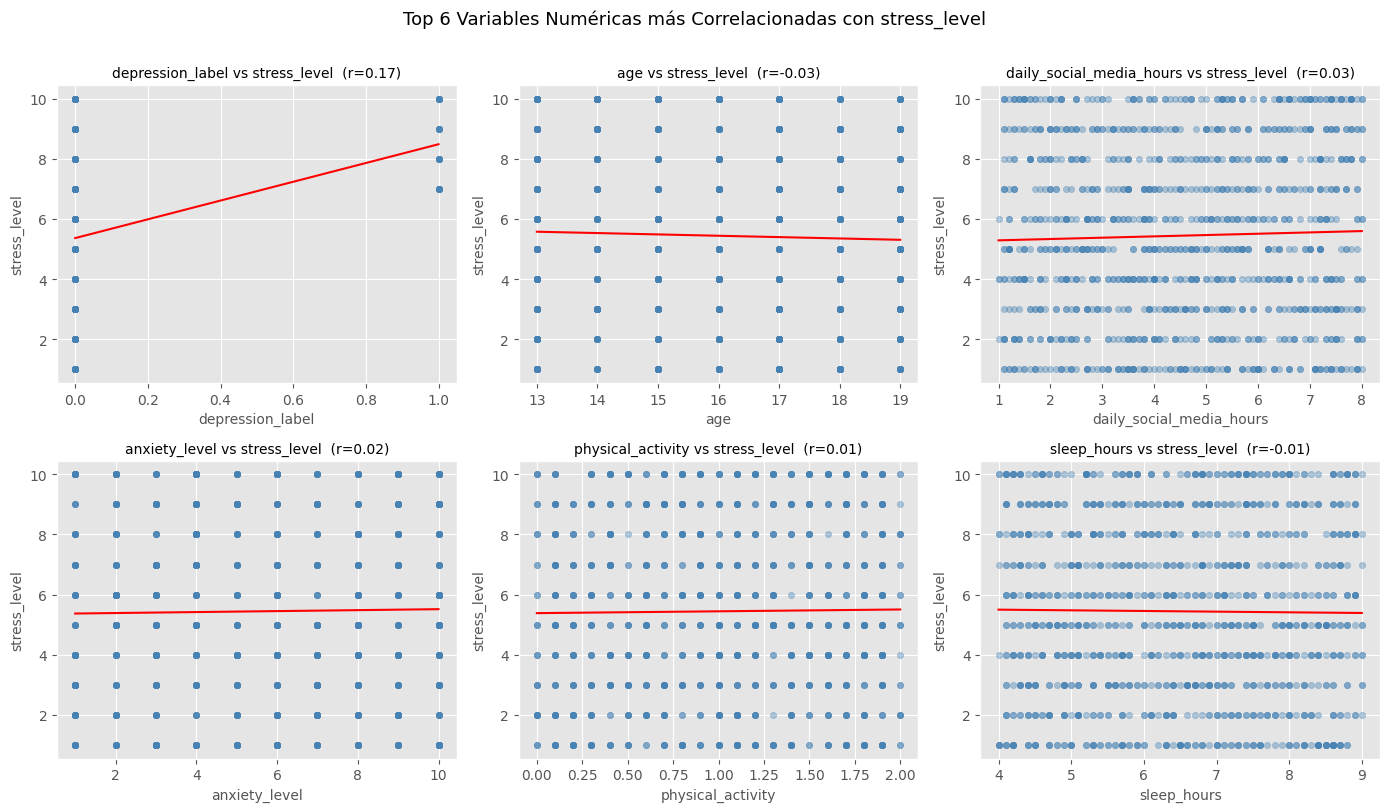

In [12]:
# Scatter plots de las 6 variables numéricas más correlacionadas con stress_level
top_vars = corr_stress.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    axes[i].scatter(df[var], df['stress_level'], alpha=0.4, color='steelblue', s=20)
    m, b = np.polyfit(df[var], df['stress_level'], 1)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('stress_level', fontsize=10)
    axes[i].set_title(f'{var} vs stress_level  (r={df[var].corr(df["stress_level"]):.2f})', fontsize=10)

plt.suptitle('Top 6 Variables Numéricas más Correlacionadas con stress_level', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## PREPARACIÓN DE DATOS Y AJUSTE DEL MODELO

Las variables categóricas (`gender`, `platform_usage`, `social_interaction_level`) se convierten en **variables dummy** para poder incluirlas en el modelo.

In [13]:
# Codificación de variables categóricas con get_dummies (drop_first evita multicolinealidad)
df_model = pd.get_dummies(df, columns=['gender', 'platform_usage', 'social_interaction_level'],
                          drop_first=True, dtype=int)

print("Columnas después de codificar:")
print(df_model.columns.tolist())
print(f"\nNuevas dimensiones: {df_model.shape}")

Columnas después de codificar:
['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'anxiety_level', 'addiction_level', 'depression_label', 'stress_level', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_low', 'social_interaction_level_medium']

Nuevas dimensiones: (1200, 15)


In [14]:
# Selección de variables independientes (X) y dependiente (y)
y = df_model['stress_level']
X = df_model.drop(columns=['stress_level'])

feature_names = X.columns.tolist()
print("Variables predictoras:")
print(feature_names)

Variables predictoras:
['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'anxiety_level', 'addiction_level', 'depression_label', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_low', 'social_interaction_level_medium']


### Dividiendo la data en entrenamiento (training) 80% y prueba (test) 20%

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size   = 0.8,
    random_state = 42,
    shuffle      = True
)

print(f"\nTrain: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")


Train: 960 muestras | Test: 240 muestras


In [16]:
# Escalado de características (solo las variables numéricas continuas)
# Las variables dummy NO se escalan
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours',
            'screen_time_before_sleep', 'academic_performance',
            'physical_activity', 'anxiety_level', 'addiction_level', 'depression_label']

scaler = StandardScaler()

X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols]  = scaler.transform(X_test[num_cols])

X_train_sc = pd.DataFrame(X_train_sc, columns=feature_names)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=feature_names)

X_train_sc.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
331,0.020422,0.766421,1.135845,-0.476546,0.476375,1.029629,-1.598783,-0.553219,-0.163517,0,1,0,1,0
409,-0.469701,0.569455,0.720924,0.915253,-0.268164,0.513021,1.560029,-1.256185,-0.163517,0,1,0,0,1
76,-1.449946,-1.695645,0.444311,0.080173,-0.770295,-0.347993,-0.194867,1.555678,-0.163517,1,0,1,0,0
868,0.020422,0.372490,-1.491985,-0.337366,-0.787610,-1.209007,0.507092,1.555678,6.115554,0,0,1,0,0
138,-0.959824,0.914145,-0.316377,-0.894086,1.411378,-0.175790,-1.247804,-0.904702,-0.163517,0,1,0,0,1


## Entrenar el modelo

In [17]:
print("\n" + "=" * 55)
print("MODELO STATSMODELS (con estadísticos completos)")
print("=" * 55)

X_train_sm = sm.add_constant(X_train_sc)
X_test_sm  = sm.add_constant(X_test_sc)

model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())


MODELO STATSMODELS (con estadísticos completos)
                            OLS Regression Results                            
Dep. Variable:           stress_level   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     2.894
Date:                Sun, 03 May 2026   Prob (F-statistic):           0.000263
Time:                        22:37:04   Log-Likelihood:                -2374.0
No. Observations:                 960   AIC:                             4778.
Df Residuals:                     945   BIC:                             4851.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

In [18]:
# Modelo con SCIKIT-LEARN
modelo = LinearRegression()
modelo.fit(X=X_train_sc, y=y_train)

LinearRegression()

### Hacer predicciones y evaluar el modelo
(Predicting the Test set results)

In [19]:
y_pred_train = modelo.predict(X_train_sc)
y_pred_test  = modelo.predict(X_test_sc)

In [20]:
y_pred_test

array([5.17806448, 5.18191686, 5.07909186, 5.54861758, 5.60579347,
       5.1458118 , 5.39114462, 5.53777122, 5.49927699, 5.26055259,
       4.83571139, 5.40293556, 5.81481653, 4.73888882, 5.34461299,
       5.75099493, 4.98182916, 5.40667276, 5.80664185, 5.71606245,
       5.10193106, 5.11644562, 5.36963358, 5.47144753, 5.03456887,
       5.30885315, 4.75247653, 5.34641039, 5.51810086, 5.25360374,
       5.6921662 , 5.34339923, 5.71014089, 5.27422851, 5.19503658,
       5.08542915, 5.55421785, 5.77933492, 8.60539496, 5.08482796,
       5.78910523, 5.34528296, 5.36737079, 5.54637639, 8.54930477,
       5.83017124, 5.2516135 , 5.30240104, 6.00944657, 5.03739821,
       8.2878735 , 5.18144896, 5.326609  , 8.3781993 , 5.84470195,
       5.12392731, 5.21773252, 5.26564291, 5.75576505, 5.27747475,
       5.46437197, 5.48077508, 5.32519778, 4.93175736, 5.35513413,
       5.68921226, 4.69801272, 5.62561066, 5.71927113, 5.31683656,
       5.31384797, 5.37015549, 8.34292333, 5.2434205 , 5.48648

In [21]:
mse  = mean_squared_error(y_true=y_test, y_pred=y_pred_test)
rmse = np.sqrt(mse)
print('Error Cuadrático Medio (MSE)  = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))

Error Cuadrático Medio (MSE)  = 7.863259419178413
Raíz del Error Cuadrático Medio (RMSE) = 2.8041503916834443


In [22]:
# Métricas completas
def print_metrics(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    print(f"  R²    : {r2:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  MSE   : {mse:.4f}")

print("\n" + "=" * 55)
print("MÉTRICAS DE EVALUACIÓN")
print("=" * 55)
print_metrics(y_train, y_pred_train, "ENTRENAMIENTO")
print_metrics(y_test,  y_pred_test,  "PRUEBA (TEST)")


MÉTRICAS DE EVALUACIÓN

────────────────────────────────────────
  ENTRENAMIENTO
────────────────────────────────────────
  R²    : 0.0411
  RMSE  : 2.8691
  MAE   : 2.4739
  MSE   : 8.2316

────────────────────────────────────────
  PRUEBA (TEST)
────────────────────────────────────────
  R²    : -0.0141
  RMSE  : 2.8042
  MAE   : 2.3870
  MSE   : 7.8633


In [23]:
# Cross-Validation (5-fold)
cv_scores = cross_val_score(
    LinearRegression(), X_train_sc, y_train,
    cv=5, scoring='r2'
)
print(f"\n  Cross-Val R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


  Cross-Val R² (5-fold): 0.0058 ± 0.0200


In [24]:
# Coeficientes e importancia de variables
coef_df = pd.DataFrame({
    'Variable'   : feature_names,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print("\n--- Coeficientes (estandarizados) ---")
print(coef_df.to_string(index=False))


--- Coeficientes (estandarizados) ---
                       Variable  Coeficiente
               depression_label     0.559908
          platform_usage_TikTok    -0.307967
   social_interaction_level_low    -0.216642
       platform_usage_Instagram    -0.142605
                            age    -0.136025
                    sleep_hours     0.129324
              physical_activity     0.106605
                  anxiety_level    -0.071043
                    gender_male     0.062676
           academic_performance    -0.040901
                addiction_level     0.025289
       screen_time_before_sleep    -0.020459
       daily_social_media_hours    -0.020042
social_interaction_level_medium    -0.017085


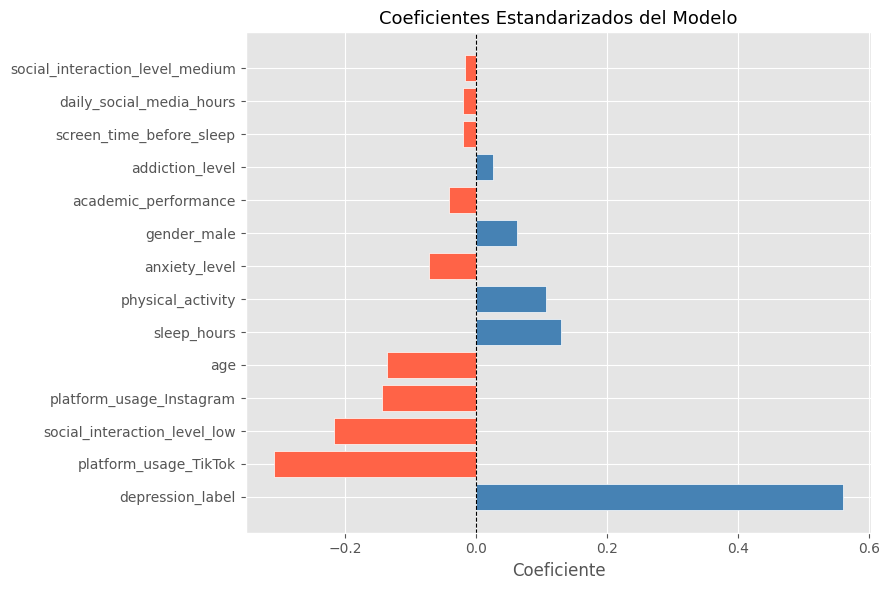

In [25]:
# Gráfico de coeficientes
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Coeficientes Estandarizados del Modelo', fontsize=13)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

## ANÁLISIS DE MULTICOLINEALIDAD (VIF)

In [26]:
print("\n" + "=" * 55)
print("FACTOR DE INFLACIÓN DE VARIANZA (VIF)")
print("=" * 55)

X_vif = sm.add_constant(X_train_sc)
vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF']      = [variance_inflation_factor(X_vif.values, i)
                        for i in range(X_vif.shape[1])]

print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))
print("\nVIF < 5: sin multicolinealidad | VIF 5–10: moderada | VIF > 10: alta")


FACTOR DE INFLACIÓN DE VARIANZA (VIF)
                       Variable      VIF
                          const 6.527655
social_interaction_level_medium 1.407239
   social_interaction_level_low 1.397905
          platform_usage_TikTok 1.349063
       platform_usage_Instagram 1.337614
               depression_label 1.111349
                    sleep_hours 1.052322
                  anxiety_level 1.042720
       daily_social_media_hours 1.039065
       screen_time_before_sleep 1.015913
                addiction_level 1.012853
                            age 1.012224
                    gender_male 1.012206
           academic_performance 1.011810
              physical_activity 1.008530

VIF < 5: sin multicolinealidad | VIF 5–10: moderada | VIF > 10: alta


## DIAGNÓSTICO DE RESIDUOS

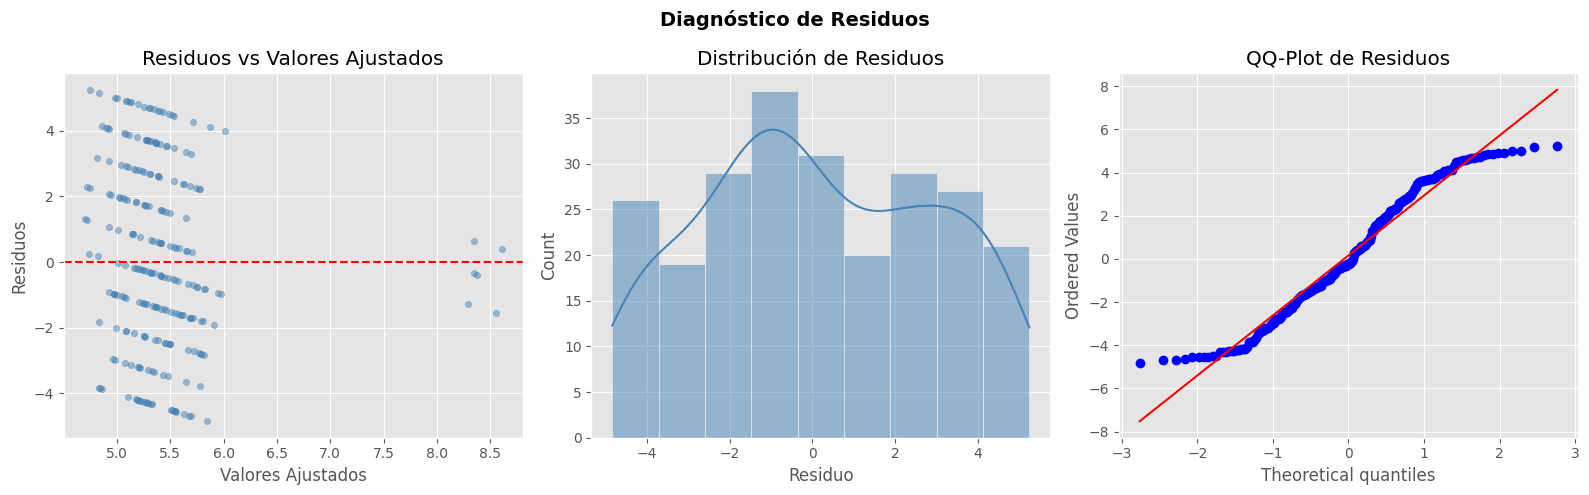

In [27]:
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residuos vs Valores Ajustados
axes[0].scatter(y_pred_test, residuals, alpha=0.5, color='steelblue', s=20)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores Ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Valores Ajustados')

# 2. Distribución de Residuos
sns.histplot(residuals, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Residuo')

# 3. QQ-Plot
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot de Residuos')

plt.suptitle('Diagnóstico de Residuos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

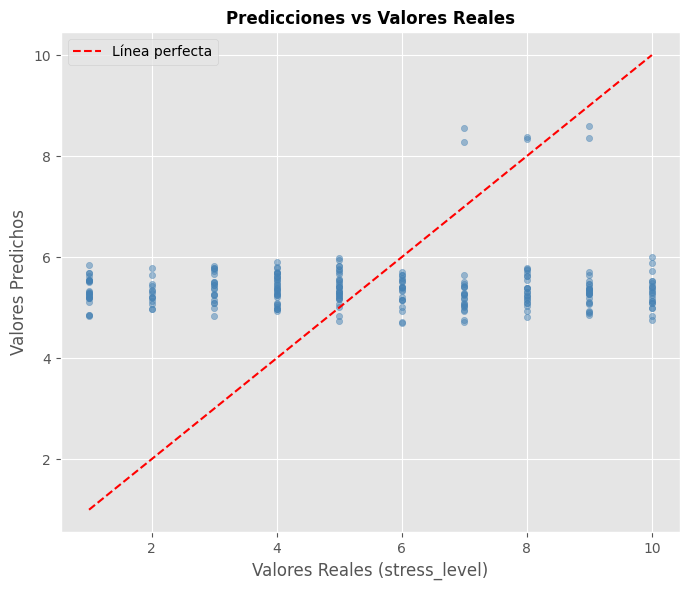

In [28]:
# Predicciones vs Valores Reales
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_test, alpha=0.5, color='steelblue', s=20)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, color='red', linestyle='--', linewidth=1.5, label='Línea perfecta')
ax.set_xlabel('Valores Reales (stress_level)')
ax.set_ylabel('Valores Predichos')
ax.set_title('Predicciones vs Valores Reales', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## ELIMINANDO VARIABLES NO SIGNIFICATIVAS

Revisar el summary de statsmodels: eliminar variables con **p-value > 0.05**.

In [29]:
# Identificar variables NO significativas (p > 0.05)
pvalues = model_sm.pvalues.drop('const')
no_sig  = pvalues[pvalues > 0.05].index.tolist()
print("Variables NO significativas (p > 0.05):")
print(no_sig)

Variables NO significativas (p > 0.05):
['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'anxiety_level', 'addiction_level', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_low', 'social_interaction_level_medium']


In [30]:
# Eliminar variables no significativas y re-entrenar
X_train_sig = X_train_sc.drop(columns=no_sig)
X_test_sig  = X_test_sc.drop(columns=no_sig)
feature_names_sig = X_train_sig.columns.tolist()

print("Variables SIGNIFICATIVAS restantes:")
print(feature_names_sig)

Variables SIGNIFICATIVAS restantes:
['depression_label']


In [31]:
print("\n" + "=" * 55)
print("MODELO CON VARIABLES SIGNIFICATIVAS (statsmodels)")
print("=" * 55)

X_train_sm2 = sm.add_constant(X_train_sig)
X_test_sm2  = sm.add_constant(X_test_sig)

model_sm2 = sm.OLS(y_train, X_train_sm2).fit()
print(model_sm2.summary())


MODELO CON VARIABLES SIGNIFICATIVAS (statsmodels)
                            OLS Regression Results                            
Dep. Variable:           stress_level   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     31.24
Date:                Sun, 03 May 2026   Prob (F-statistic):           2.97e-08
Time:                        22:37:05   Log-Likelihood:                -2378.8
No. Observations:                 960   AIC:                             4762.
Df Residuals:                     958   BIC:                             4771.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [32]:
# Modelo final con scikit-learn
modelo2 = LinearRegression()
modelo2.fit(X=X_train_sig, y=y_train)

y_pred_train2 = modelo2.predict(X_train_sig)
y_pred_test2  = modelo2.predict(X_test_sig)

print("\n" + "=" * 55)
print("MÉTRICAS — MODELO CON VARIABLES SIGNIFICATIVAS")
print("=" * 55)
print_metrics(y_train, y_pred_train2, "ENTRENAMIENTO")
print_metrics(y_test,  y_pred_test2,  "PRUEBA (TEST)")

cv_scores2 = cross_val_score(
    LinearRegression(), X_train_sig, y_train,
    cv=5, scoring='r2'
)
print(f"\n  Cross-Val R² (5-fold): {cv_scores2.mean():.4f} ± {cv_scores2.std():.4f}")


MÉTRICAS — MODELO CON VARIABLES SIGNIFICATIVAS

────────────────────────────────────────
  ENTRENAMIENTO
────────────────────────────────────────
  R²    : 0.0316
  RMSE  : 2.8833
  MAE   : 2.4877
  MSE   : 8.3134

────────────────────────────────────────
  PRUEBA (TEST)
────────────────────────────────────────
  R²    : 0.0146
  RMSE  : 2.7641
  MAE   : 2.3409
  MSE   : 7.6405

  Cross-Val R² (5-fold): 0.0243 ± 0.0173


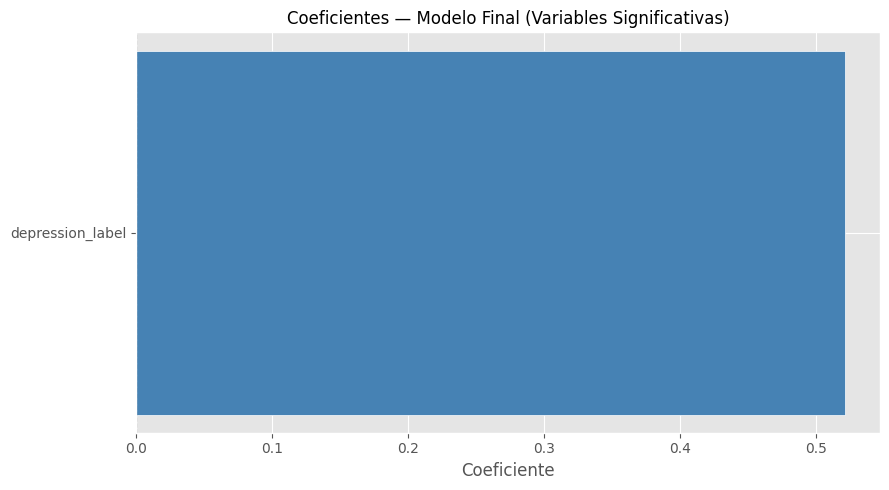

In [33]:
# Coeficientes del modelo final
coef_df2 = pd.DataFrame({
    'Variable'   : feature_names_sig,
    'Coeficiente': modelo2.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors2 = ['tomato' if c < 0 else 'steelblue' for c in coef_df2['Coeficiente']]
ax.barh(coef_df2['Variable'], coef_df2['Coeficiente'], color=colors2, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Coeficientes — Modelo Final (Variables Significativas)', fontsize=12)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()